<a href="https://colab.research.google.com/github/PacktPublishing/Modern-Computer-Vision-with-PyTorch-2E/blob/main/Chapter07/Understanding_selectivesearch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
#%pip install selectivesearch
#%pip install torch_snippets
from torch_snippets import *
import selectivesearch
from skimage.segmentation import felzenszwalb

In [24]:
from skimage.transform import  resize

In [25]:
help(read)

Help on function read in module torch_snippets.loader:

read(fname, mode=1)



In [26]:
#!wget -q https://www.dropbox.com/s/lpw10qawsc5ipbn/MyImage.JPG -O MyImage.jpg
img = read('eu.jpg',1)

In [27]:
img_r = resize(img,(img.shape[0]//4,img.shape[1]//4))

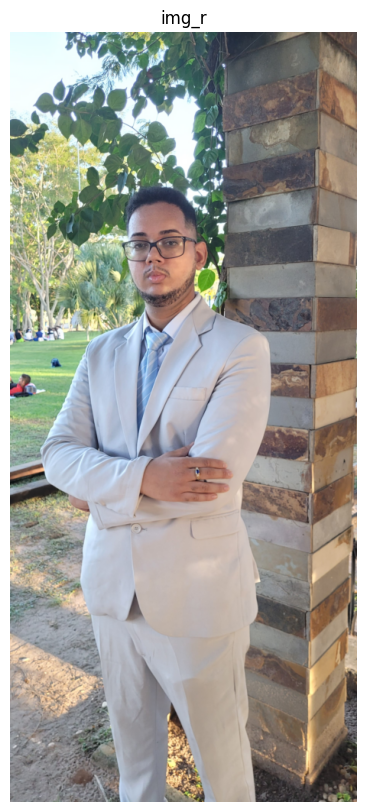

In [28]:
show(img_r)

In [29]:
import numpy as np

In [30]:
x = np.array([
    [4,7],
    [5,6]
    ])
x.prod(axis=1)

array([28, 30])

In [31]:
x[:2]

array([[4, 7],
       [5, 6]])

In [32]:
np.prod(x[:2])

840

In [34]:
segments_fz = felzenszwalb(img_r, scale=200)

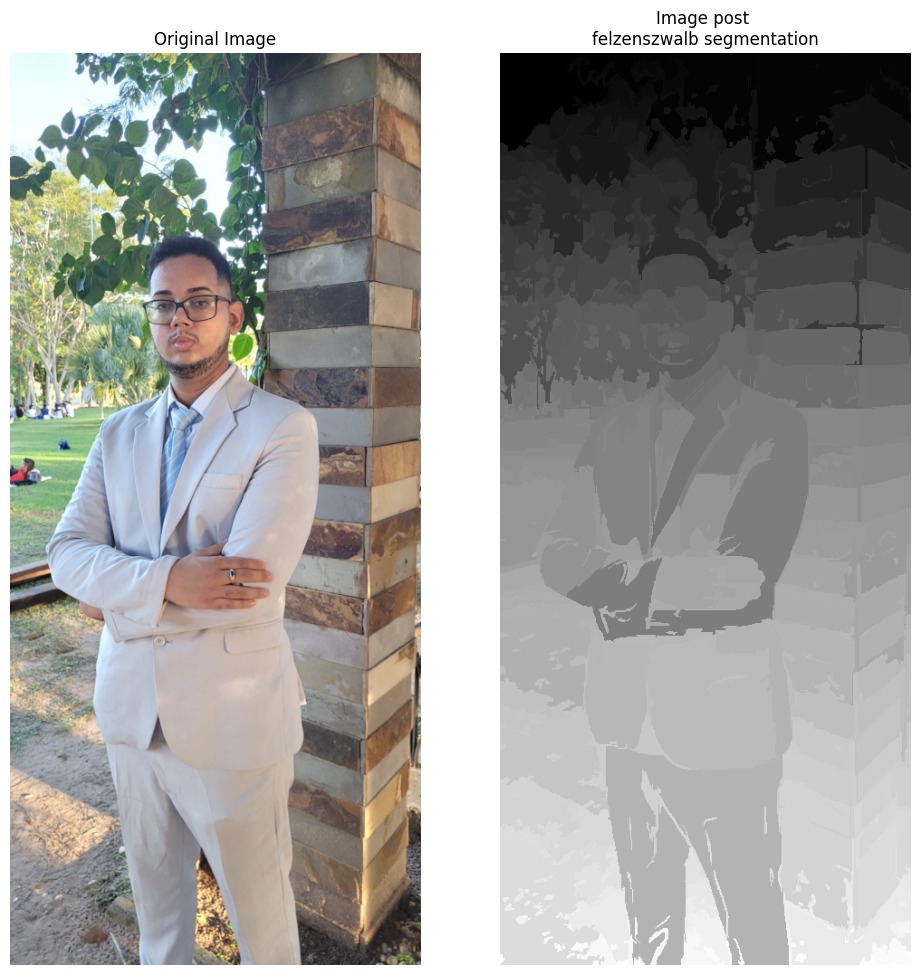

In [35]:
subplots([img_r, segments_fz], titles=['Original Image','Image post \nfelzenszwalb segmentation'], figsize=(10,10), nc=2)

In [36]:
def extract_candidates(img):
    img_lbl, regions = selectivesearch.selective_search(img, scale=200, min_size=100)
    img_area = np.prod(img.shape[:2])
    candidates = []
    for r in regions:
        if r['rect'] in candidates: continue
        if r['size'] < (0.05*img_area): continue
        if r['size'] > (1*img_area): continue
        x, y, w, h = r['rect']
        candidates.append(list(r['rect']))
    return candidates


In [ ]:
#%pip install selectivesearch
#%pip install torch_snippets
from torch_snippets import *
import selectivesearch
# !wget https://www.dropbox.com/s/l98leemr7r5stnm/Hemanvi.jpeg
# img = read('Hemanvi.jpeg', 1)

In [ ]:
np.clip()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


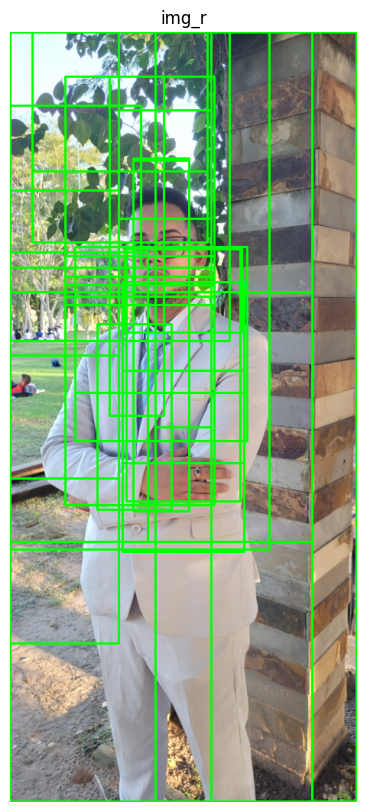

In [42]:
candidates = extract_candidates(img_r)
show(img_r, bbs = candidates)